# Object Reference Frame vs. Solar Wind Reference Frame



In [1]:
from menura_utils import *
import own_tools as oT
import own_colours as oC

In [5]:
idx_it = 2000
path = '../Data/run_010'
md_turb = menura_data(path, '', idx_it, ask_scp=False)
path = '../Data/run_011'
md_lami = menura_data(path, '', idx_it, ask_scp=False)


._____________________________________________________________________________________
| Physical run parameters:
|    
| 1 process.
|
| Dimensionality:                  2D 
|
| B_0:                              2.50e-09 T
| n_0:                              1.00e+06 m^-3
| T_eon:                            1.80e+05 K
| T_ion:                            1.80e+05 K
|
| Proton plasma frequency:         1316.5700 rad/s
| Proton gyrofrequency:               0.2394 rad/s
| Electron plasma frequency:       5.6422e+04 rad/s
| Electron gyrofrequency:           439.6750 rad/s
|
| Proton inertial length d_i :      227.7080 km
| Electron inertial length d_e :      5.3134 km
| Debye length lambda_D :             0.0293 km
| Gyro-radius (v_th) :                1.0000
|
| Alfven speed :                     54.5161 km/s
| Sound speed :                      77.0973 km/s
| Magnetosonic speed :               94.4246 km/s
| Ion thermal speed :                54.5161 km/s
| Electron thermal speed :      

In [3]:
def plt_comparison(field_1, field_2, md_1, md_2, vminmax=None, cmap=oC.bwr_2, save_plot=False):
    
    if vminmax is None:
        vmin = -1
        vmax = 1
    else:
        vmin = vminmax[0]
        vmax = vminmax[1]
            
    fig, AX = plt.subplots(1, 2, figsize=(16, 12))
    for ax in AX:
        ax.set_aspect('equal')

    p0 = AX[0].pcolormesh(md_1.edges_x_box, md_1.edges_y_box, field_1.T,
                               vmin=vmin, vmax=vmax,
                               cmap=cmap, rasterized=True)

    p1 = AX[1].pcolormesh(md_2.edges_x_box, md_2.edges_y_box, field_2.T,
                               vmin=vmin, vmax=vmax,
                               cmap=cmap, rasterized=True)

    #        idx_y = int((.9-1.)*md.nb_proc*md.mp.len_y_cst+self.mp.len_y_cst)
     #       ax.text(self.edges_x[-1, int(.1*self.mp.len_x_cst)], self.edges_y[-1, idx_y], label, ha='center', va='center', fontsize=20)

    #posAx = ax.get_position()
    #cax = self.fig2.add_axes([posAx.x1*1., posAx.y0, 0.02, .3])
    #cb = self.fig2.colorbar(p0, cax=cax, orientation='vertical')
    # cb.set_label(label, rotation=0, ha='left', fontsize=24)

    oT.set_spines(AX)
    plt.tight_layout()
    if save_plot:
        plt.savefig('yo.pdf')
    else:
        plt.show()
    
    

## Solar wind density
First the solar wind density, log10, red being denser than upstream, blue less dense.

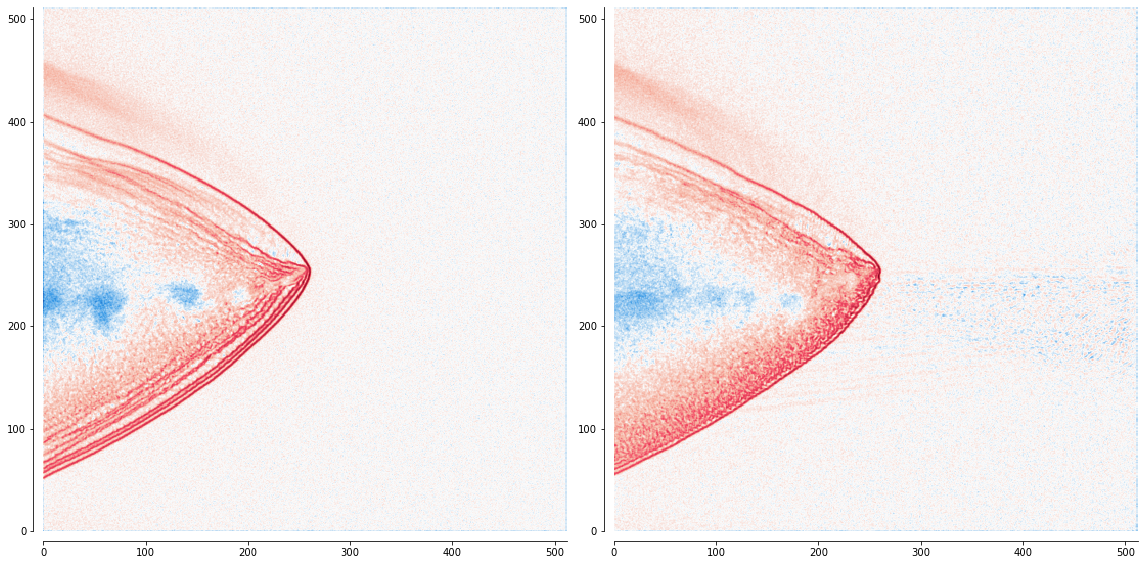

In [6]:
dens_sw_turb = md_turb.recompose_field(md_turb.dens_spec0)
dens_sw_lami = md_lami.recompose_field(md_lami.dens_spec0)
dens_sw_turb = np.log10(dens_sw_turb)
dens_sw_lami = np.log10(dens_sw_lami)
plt_comparison(dens_sw_lami, dens_sw_turb, md_lami, md_turb, vminmax=[-.8, .8])

## Cometary ion density
Second the cometary ions, log10.

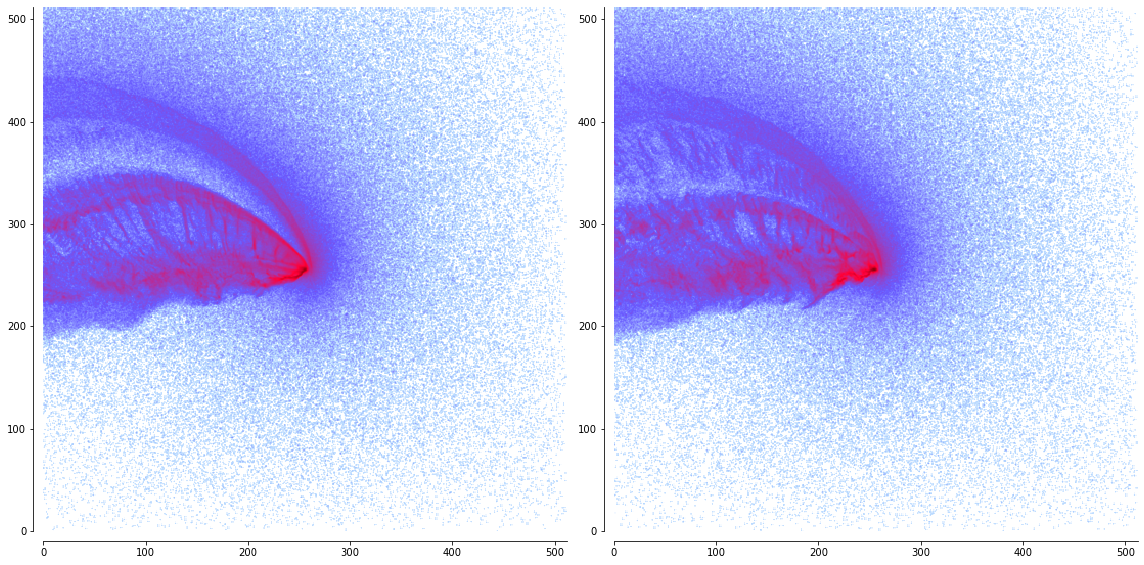

In [7]:
dens_pla_turb = md_turb.recompose_field(md_turb.dens_spec1)
dens_pla_lami = md_lami.recompose_field(md_lami.dens_spec1)
dens_pla_turb = np.log10(dens_pla_turb)
dens_pla_lami = np.log10(dens_pla_lami)
plt_comparison(dens_pla_lami, dens_pla_turb, md_lami, md_turb, vminmax=[-4, 1], cmap=oC.wbr_1)

## In-plane/perpendicular B-field
Also log10.

(512, 512)


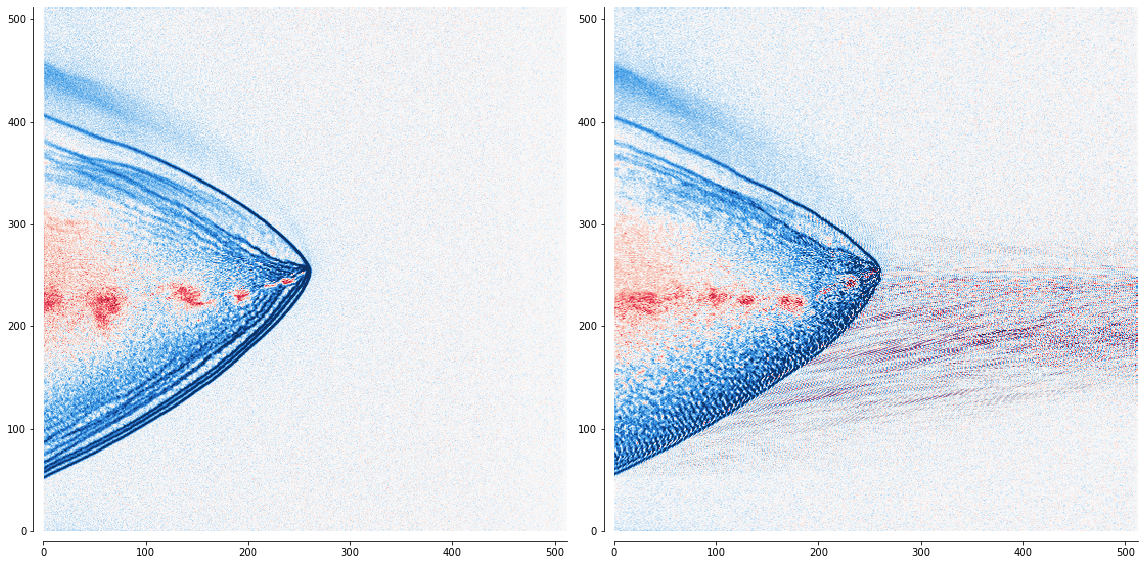

In [8]:
dens_pla_turb = md_turb.recompose_field(md_turb.B[:, 2])
dens_pla_lami = md_lami.recompose_field(md_lami.B[:, 2])
print(dens_pla_turb.shape)
plt_comparison(dens_pla_lami, dens_pla_turb, md_lami, md_turb, vminmax=[-2.5, .5], cmap=oC.bwr_2, save_plot=True)